# Proyek Klasifikasi Gambar: skin-cancer-isic-images
- **Nama:** Given Glorious
- **Email:** givenglorious@gmail.com
- **ID Dicoding:** [Input Username]

## Import Semua Packages/Library yang Digunakan

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout,GlobalAveragePooling2D,BatchNormalization, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import zipfile
import warnings
warnings.filterwarnings('ignore')

import tensorflow.keras.layers as layers

In [ ]:
with zipfile.ZipFile("/content/sample_data/dataset 4.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset_folder")

## Data Preparation

### Data Loading

In [ ]:
def load_data_from_folder(folder) :
    images = []
    for filenames in os.listdir(folder) :
            img = Image.open(os.path.join(folder, filenames))
            img = img.resize((224,224)) 
            img = img.convert('RGB')
            img = np.array(img) / 255.0
            images.append(img)
    return images

In [4]:
benign_images = load_data_from_folder('/content/dataset_folder/dataset 4/benign')
malignant_images = load_data_from_folder('/content/dataset_folder/dataset 4/malignant')

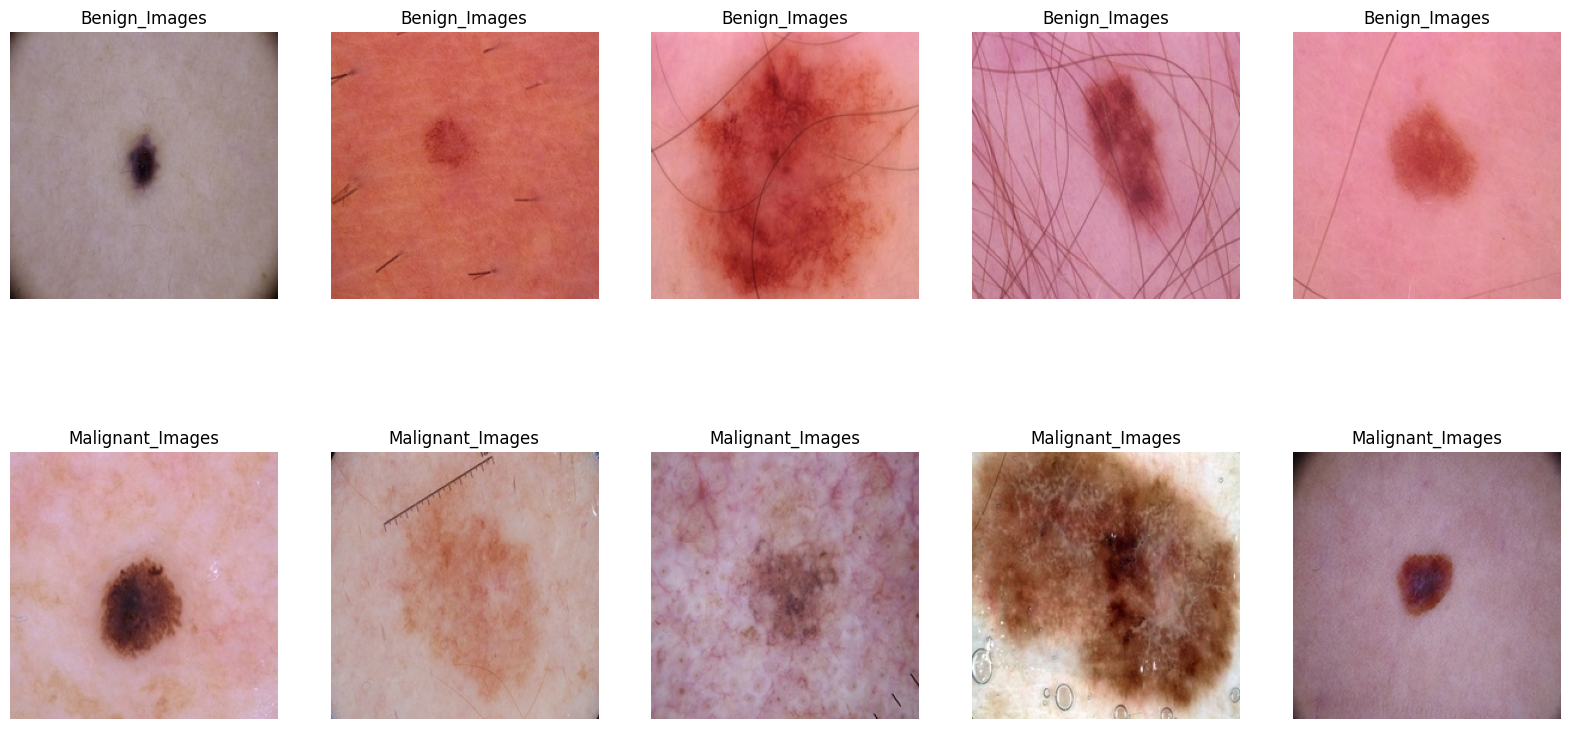

In [5]:
fig,axes = plt.subplots(2,5 ,figsize=(20,10))
for i in range(5):
    axes[0,i].imshow(benign_images[i])
    axes[0,i].set_title('Benign_Images')
    axes[0,i].axis('off')

for i in range(5):
    axes[1,i].imshow(malignant_images[i])
    axes[1,i].set_title('Malignant_Images')
    axes[1,i].axis('off')
plt.show()

In [6]:
def label(benign_images,malignant_images):
    #1 (malignant)
    malignant_label = np.ones(len(malignant_images))
    #0 (benign)
    benign_label = np.zeros(len(benign_images))
    return malignant_label,benign_label
#Ubah Nama Varibel
benign_labels,malignant_labels, = label(benign_images,malignant_images)

In [7]:
print(benign_labels.shape)
print(malignant_labels.shape)

(500,)
(500,)


In [8]:
# COMBINE DATA
data = benign_images + malignant_images
labels = np.concatenate([benign_labels,malignant_labels],axis=0)
labels

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [9]:
data[0].shape

(224, 224, 3)

### Data Preprocessing

In [10]:
X = np.array(data)
y = np.array(labels)

#### Split Dataset

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [12]:
train = tf.data.Dataset.from_tensor_slices((X_train,y_train))
test = tf.data.Dataset.from_tensor_slices((X_test,y_test))

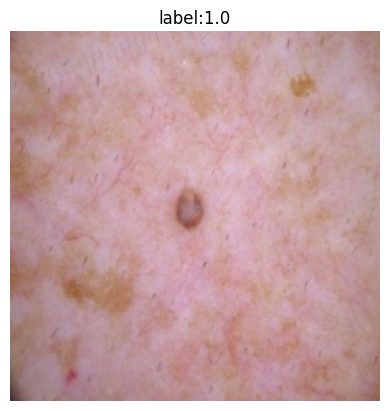

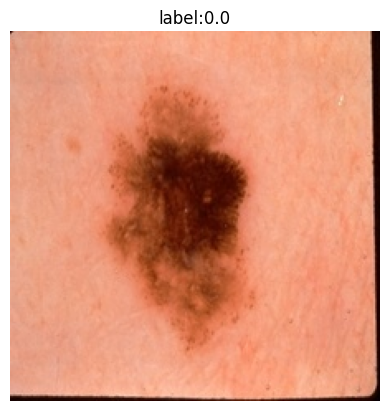

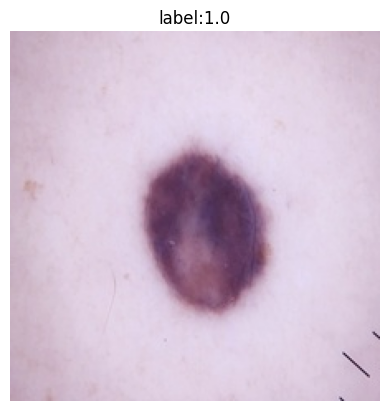

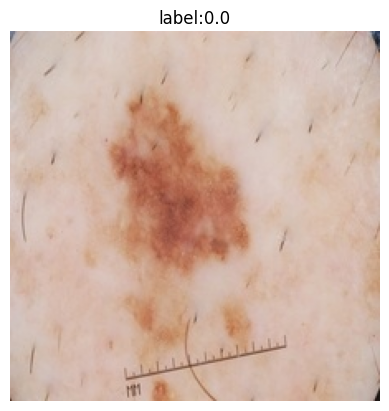

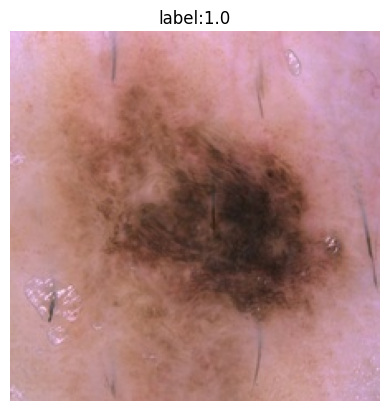

In [13]:
for image,label in train.take(5):


    plt.figure()
    plt.imshow(image.numpy())
    plt.title('label:{}'.format(label.numpy()))
    plt.axis('off')
    plt.show()

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
dataset = dataset.shuffle(len(X_train))

val_size = int(0.1 * len(X_train))
train = train.shuffle(1000)
val = dataset.take(val_size)
train = dataset.skip(val_size)

In [ ]:
train = train.batch(32).prefetch(tf.data.AUTOTUNE)
val = val.batch(32).prefetch(tf.data.AUTOTUNE)
test = test.batch(32).prefetch(tf.data.AUTOTUNE)

## Modelling

In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [ ]:
model = Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    base_model,

    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate= 0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train,
    validation_data=val,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.5946 - loss: 0.6821 - val_accuracy: 0.5500 - val_loss: 0.7294 - learning_rate: 1.0000e-04
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.6856 - loss: 0.5926 - val_accuracy: 0.7750 - val_loss: 0.4571 - learning_rate: 1.0000e-04
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7569 - loss: 0.5189 - val_accuracy: 0.8375 - val_loss: 0.4026 - learning_rate: 1.0000e-04
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.7910 - loss: 0.4665 - val_accuracy: 0.8375 - val_loss: 0.4304 - learning_rate: 1.0000e-04
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.7929 - loss: 0.4519 - val_accuracy: 0.8000 - val_loss: 0.3315 - learning_rate: 1.0000e-04
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8357 - loss: 0.4116 - val_accuracy: 0.7375 - val_loss: 0.4290 - learning_rate: 1.0000e-04
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.84

In [51]:
test_set = model.evaluate(test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8514 - loss: 0.3629


## Evaluasi dan Visualisasi

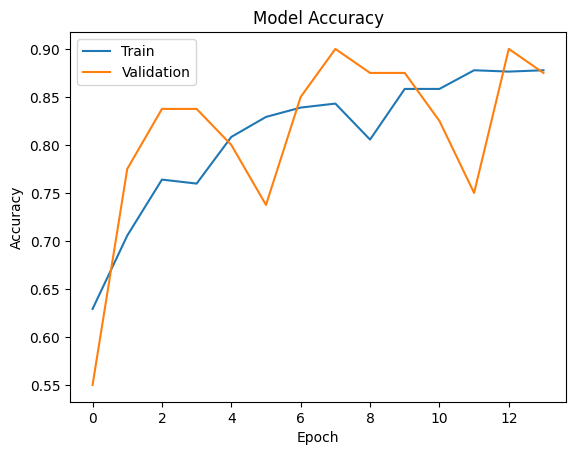

In [52]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

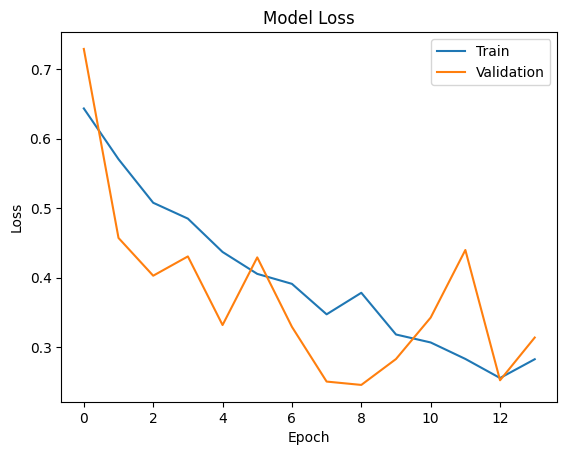

In [53]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

## Konversi Model

In [68]:
model.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_583')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133603559301264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603559302416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133603559302608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933410384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933410576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933409616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933409232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933411152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933410192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933410768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933410960

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()


with open("tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

labels = ["benign", "malignant"]

with open("tflite/label.txt", "w") as f:
    for label in labels:
        f.write(label + "\n")

Saved artifact at '/tmp/tmpp0pu32gr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_583')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133600933410384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933410576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933409616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933409232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933411152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933410192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933410768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933410960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933407312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133600933412112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1336009334

In [ ]:
import tensorflowjs as tfjs
tfjs.converters.save_keras_model(model, "tfjs_model")

failed to lookup keras version from the file,
    this is likely a weight only file


In [70]:
from google.colab import files
files.download('tflite/model.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
!zip -r output.zip tfjs_model tflite
from google.colab import files
files.download("output.zip")

  adding: tfjs_model/ (stored 0%)
  adding: tfjs_model/model.json (deflated 96%)
  adding: tfjs_model/group1-shard1of3.bin (deflated 7%)
  adding: tfjs_model/group1-shard3of3.bin (deflated 7%)
  adding: tfjs_model/group1-shard2of3.bin (deflated 7%)
  adding: tflite/ (stored 0%)
  adding: tflite/label.txt (stored 0%)
  adding: tflite/model.tflite (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
!zip -r saved_model.zip saved_model
from google.colab import files
files.download("saved_model.zip")

  adding: saved_model/ (stored 0%)
  adding: saved_model/assets/ (stored 0%)
  adding: saved_model/fingerprint.pb (stored 0%)
  adding: saved_model/saved_model.pb (deflated 90%)
  adding: saved_model/variables/ (stored 0%)
  adding: saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: saved_model/variables/variables.index (deflated 77%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference (Optional)